# GEC Pretrained Classifier with 5-Fold Stratified Cross-Validation

In [ ]:
import json
import numpy as np
import os
import torch
from sklearn.model_selection import StratifiedKFold
from collections import OrderedDict
from pathlib import Path
from torch_geometric.loader import DataLoader
from model.GEC.dataset import ClassificationDataset, CombinedClassificationDataset
from model.GEC.models import GraphEncoderClassifierAttention
from model.GEC.utils import load_checkpoint, save_checkpoint, calculate_metrics
from model.GEC.losses import weighted_binary_cross_entropy
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
sns.set(style="whitegrid")
...
results_file = os.path.join(run_artifact_dir, "cv_results.json")
with open(results_file, 'w') as f:
    def convert(o):
        if isinstance(o, np.float32):
            return float(o)
        raise TypeError(f"Object of type {o.__class__.__name__} is not JSON serializable")
    json.dump(results_to_save, f, indent=2, default=convert)
print(f"Saved CV results to {results_file}")
print(f"\nUse this checkpoint directory for testing: {run_artifact_dir}")

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Configuration

In [21]:
try:
    wandb.login()
except Exception:
    pass

WANDB_PROJECT = "gec-converter-classification-dmn"

In [ ]:
# DMN data and metadata paths
DMN_ROOT = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v5__/dmn_only_schaefer'
METADATA_DIR = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__v5__/metadata'
GEC_SPLITS_DIR = os.path.join(METADATA_DIR, 'splits_gec')
TRAIN_SPLIT_CSV = os.path.join(GEC_SPLITS_DIR, 'train.csv')
VAL_SPLIT_CSV = os.path.join(GEC_SPLITS_DIR, 'val.csv')
TEST_SPLIT_CSV = os.path.join(GEC_SPLITS_DIR, 'test.csv')

# Verify that split files exist
assert os.path.exists(TRAIN_SPLIT_CSV), f"Missing split file: {TRAIN_SPLIT_CSV}"
assert os.path.exists(VAL_SPLIT_CSV), f"Missing split file: {VAL_SPLIT_CSV}"
assert os.path.exists(TEST_SPLIT_CSV), f"Missing split file: {TEST_SPLIT_CSV}"

# GAAE checkpoint search root (single source of truth)
CHECKPOINT_SEARCH_DIRS = [
    str(model_root / 'notebooks' / 'checkpoints_gaae'),
]

# GEC output directory
GEC_OUTPUT_DIR = str(model_root / 'notebooks' / 'checkpoints_gec')
os.makedirs(GEC_OUTPUT_DIR, exist_ok=True)

IN_FEATURES = 46
HIDDEN_DIM = 46
LATENT_DIM = 32
COND_DIM = 2
NUM_HEADS = 2
DROPOUT = 0.5
CLASSIFIER_HIDDEN = 32

BATCH_SIZE = 16
LEARNING_RATE = 0.001
EPOCHS = 25
EARLY_STOPPING_PATIENCE = 30

KNN_K = 8
adjacency_args = {'k': KNN_K}
CORRELATION_TYPE = 'dmn'
FILE_VARIANT = 'z_transformed'

FREEZE_ENCODER = False
CLASSIFICATION_THRESHOLD = 0.35

N_FOLDS = 5
RANDOM_STATE = 42

In [23]:
# Discover DMN-compatible GAAE checkpoints from configured directories
checkpoint_candidates = []
for checkpoint_dir in CHECKPOINT_SEARCH_DIRS:
    if not os.path.isdir(checkpoint_dir):
        continue
    for run_name in sorted(os.listdir(checkpoint_dir)):
        run_dir = os.path.join(checkpoint_dir, run_name)
        if not os.path.isdir(run_dir):
            continue
        model_file = os.path.join(run_dir, f'model_{run_name}.pth')
        if os.path.exists(model_file):
            checkpoint_candidates.append((run_name, model_file, run_dir))

if not checkpoint_candidates:
    raise FileNotFoundError(
        'No GAAE checkpoints found. Train MODEL/notebooks/GAAE_DELCODE_DMN.ipynb first.'
    )

print('Available checkpoints:')
for i, (run_name, model_file, run_dir) in enumerate(checkpoint_candidates):
    print(f'  {i}: {run_name} ({run_dir})')

selected_run_index = int(input('Select a checkpoint by index: '))
RUN_NAME, GAAE_CHECKPOINT_PATH, SELECTED_RUN_DIR = checkpoint_candidates[selected_run_index]

# Optionally align dimensions with the selected run config
run_config_path = os.path.join(SELECTED_RUN_DIR, 'run_config.json')
if os.path.exists(run_config_path):
    with open(run_config_path, 'r') as f:
        run_config = json.load(f)
    model_cfg = run_config.get('model_config', {})
    IN_FEATURES = int(model_cfg.get('in_features', IN_FEATURES))
    HIDDEN_DIM = int(model_cfg.get('hidden_size', HIDDEN_DIM))
    LATENT_DIM = int(model_cfg.get('latent_dim', LATENT_DIM))
    NUM_HEADS = int(model_cfg.get('attention_heads', NUM_HEADS))
    DROPOUT = float(model_cfg.get('dropout', DROPOUT))
    print(f"Loaded run config from {run_config_path}")

print(f'Using checkpoint: {GAAE_CHECKPOINT_PATH}')
print(f'Configured dims: in={IN_FEATURES}, latent={LATENT_DIM}, heads={NUM_HEADS}, dropout={DROPOUT}')

Available checkpoints:
  0: honest-disco-4 (/mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae/honest-disco-4)
  1: likely-wave-3 (/mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae/likely-wave-3)
Loaded run config from /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae/honest-disco-4/run_config.json
Using checkpoint: /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae/honest-disco-4/model_honest-disco-4.pth
Configured dims: in=46, latent=32, heads=2, dropout=0.5


In [24]:
if not os.path.exists(GAAE_CHECKPOINT_PATH):
    raise FileNotFoundError(f'Checkpoint not found: {GAAE_CHECKPOINT_PATH}')
print(f'Checkpoint ready: {GAAE_CHECKPOINT_PATH}')

Checkpoint ready: /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae/honest-disco-4/model_honest-disco-4.pth


## Load Datasets

In [ ]:
# Load split data and build patient_info from split CSVs (no cohorts.csv dependency)
train_split_df = pd.read_csv(TRAIN_SPLIT_CSV)
val_split_df = pd.read_csv(VAL_SPLIT_CSV)
test_split_df = pd.read_csv(TEST_SPLIT_CSV)

# Verify required columns exist
required_cols = {'Repseudonym', 'diagnosis', 'converter_status', 'sex', 'age'}
for df, name in [(train_split_df, 'train'), (val_split_df, 'val'), (test_split_df, 'test')]:
    missing = required_cols - set(df.columns)
    assert not missing, f"Split {name}.csv missing columns: {missing}"

# Combine all splits to build patient_info for dataset conditioning
all_splits_df = pd.concat([train_split_df, val_split_df, test_split_df], ignore_index=True)
all_splits_df = all_splits_df.drop_duplicates(subset=['Repseudonym'], keep='first')

# Create patient_info with Repseudonym as index, required for ClassificationDataset
patient_info_df = all_splits_df[['Repseudonym', 'sex', 'age']].copy()
patient_info_df.rename(columns={'Repseudonym': 'Pseudonym'}, inplace=True)
patient_info_df.set_index('Pseudonym', inplace=True)

# Build converter_status map for identifying converter vs non-converter subjects
converter_status_map = dict(zip(train_split_df['Repseudonym'], train_split_df['converter_status']))
converter_status_map.update(dict(zip(val_split_df['Repseudonym'], val_split_df['converter_status'])))
converter_status_map.update(dict(zip(test_split_df['Repseudonym'], test_split_df['converter_status'])))

# Collect all split IDs
split_ids = set()
for split_csv in [TRAIN_SPLIT_CSV, VAL_SPLIT_CSV, TEST_SPLIT_CSV]:
    split_df = pd.read_csv(split_csv)
    split_ids.update(split_df['Repseudonym'].astype(str).tolist())

# Derive converter and non-converter IDs from converter_status column
converter_ids = sorted([sid for sid in split_ids if converter_status_map.get(sid) == 1])
non_converter_ids = sorted([sid for sid in split_ids if converter_status_map.get(sid) == 0])

# Build patient_info_path to a temporary file for ClassificationDataset
import tempfile
patient_info_path = tempfile.NamedTemporaryFile(mode='w', suffix='.csv', delete=False).name
patient_info_df.to_csv(patient_info_path)

converter_dataset = ClassificationDataset(
    root=DMN_ROOT,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args,
    patient_info_path=patient_info_path,
    is_converter_dataset=True,
    separator=',',
    correlation_type=CORRELATION_TYPE,
    subject_ids=converter_ids,
    file_variant=FILE_VARIANT,
    filter_csv_path=None,
    converter_list_path=None,
)

mci_stable_dataset = ClassificationDataset(
    root=DMN_ROOT,
    adjacency_function=knn_binary_adjacency_matrix_no_diag,
    adjacency_args=adjacency_args,
    patient_info_path=patient_info_path,
    is_converter_dataset=False,
    separator=',',
    correlation_type=CORRELATION_TYPE,
    subject_ids=non_converter_ids,
    file_variant=FILE_VARIANT,
    filter_csv_path=None,
    converter_list_path=None,
)

print(f"Converter dataset size: {len(converter_dataset)}")
print(f"Non-converter dataset size: {len(mci_stable_dataset)}")

Converter dataset size: 196
Non-converter dataset size: 413


In [26]:
combined_dataset = CombinedClassificationDataset(converter_dataset, mci_stable_dataset)
all_labels = combined_dataset.get_labels()

print(f"\nCombined dataset:")
print(f"  Total samples: {len(combined_dataset)}")
print(f"  Converters: {sum(all_labels)} ({sum(all_labels)/len(all_labels)*100:.1f}%)")
print(f"  Non-converters: {len(all_labels) - sum(all_labels)} ({(len(all_labels)-sum(all_labels))/len(all_labels)*100:.1f}%)")


Combined dataset:
  Total samples: 609
  Converters: 196.0 (32.2%)
  Non-converters: 413.0 (67.8%)


## Load Splits from DMN Metadata CSVs

Train + validation IDs are used as the cross-validation pool.
Test IDs are used as the holdout set.

In [27]:
def read_split_ids(csv_path):
    split_df = pd.read_csv(csv_path)
    if 'Repseudonym' not in split_df.columns:
        raise ValueError(f"Split file must contain 'Repseudonym': {csv_path}")
    return set(split_df['Repseudonym'].astype(str).tolist())

train_ids = read_split_ids(TRAIN_SPLIT_CSV)
val_ids = read_split_ids(VAL_SPLIT_CSV)
test_ids = read_split_ids(TEST_SPLIT_CSV)

patient_to_indices = {}
for idx in range(len(combined_dataset)):
    patient_id = str(getattr(combined_dataset[idx], 'patient_id', ''))
    patient_to_indices.setdefault(patient_id, []).append(idx)

def get_split_indices(patient_ids):
    indices = []
    for pid in patient_ids:
        indices.extend(patient_to_indices.get(str(pid), []))
    return sorted(indices)

train_split_indices = get_split_indices(train_ids)
val_split_indices = get_split_indices(val_ids)
test_split_indices = get_split_indices(test_ids)

cv_indices = train_split_indices + val_split_indices
holdout_indices = test_split_indices

cv_labels = [all_labels[i] for i in cv_indices]
holdout_labels = [all_labels[i] for i in holdout_indices]

print('DMN Split Sizes (from metadata CSVs):')
print(f'  Train split: {len(train_split_indices)}')
print(f'  Validation split: {len(val_split_indices)}')
print(f'  Test split (holdout): {len(test_split_indices)}')

cv_pos = int(sum(cv_labels))
holdout_pos = int(sum(holdout_labels))
print(f"\nCV set: {len(cv_indices)} samples, {cv_pos} converters ({(cv_pos/len(cv_labels)*100) if cv_labels else 0:.1f}%)")
print(f"Holdout set: {len(holdout_indices)} samples, {holdout_pos} converters ({(holdout_pos/len(holdout_labels)*100) if holdout_labels else 0:.1f}%)")

DMN Split Sizes (from metadata CSVs):
  Train split: 187
  Validation split: 34
  Test split (holdout): 33

CV set: 221 samples, 170 converters (76.9%)
Holdout set: 33 samples, 26 converters (78.8%)


## 5-Fold Stratified Cross-Validation

In [28]:
cv_results = {
    'fold': [],
    'val_loss': [],
    'val_auc': [],
    'val_sensitivity': [],
    'val_specificity': [],
    'val_f1': [],
    'best_threshold': [],
    'best_epoch': []
}

best_model_state = None
best_val_auc = 0
best_fold = -1

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"Starting {N_FOLDS}-fold stratified cross-validation...")
print("=" * 60)

for fold, (train_idx_in_cv, val_idx_in_cv) in enumerate(skf.split(cv_indices, cv_labels)):
    print(f"\n{'='*60}")
    print(f"FOLD {fold + 1}/{N_FOLDS}")
    print(f"{'='*60}")
    
    train_idx = [cv_indices[i] for i in train_idx_in_cv]
    val_idx = [cv_indices[i] for i in val_idx_in_cv]
    
    train_labels_fold = [all_labels[i] for i in train_idx]
    val_labels_fold = [all_labels[i] for i in val_idx]
    
    print(f"Train: {len(train_idx)} samples, {sum(train_labels_fold)} converters ({sum(train_labels_fold)/len(train_labels_fold)*100:.1f}%)")
    print(f"Val: {len(val_idx)} samples, {sum(val_labels_fold)} converters ({sum(val_labels_fold)/len(val_labels_fold)*100:.1f}%)")
    
    train_dataset = torch.utils.data.Subset(combined_dataset, train_idx)
    val_dataset = torch.utils.data.Subset(combined_dataset, val_idx)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    pos_weight = compute_class_weights(train_labels_fold, device=device)
    
    model = GraphEncoderClassifierAttention(
        in_features=IN_FEATURES,
        hidden_dim=HIDDEN_DIM,
        latent_dim=LATENT_DIM,
        cond_dim=COND_DIM,
        num_heads=NUM_HEADS,
        dropout=DROPOUT,
        classifier_hidden=CLASSIFIER_HIDDEN
    ).to(device)
    
    model = load_frozen_encoder_from_gaae(model, GAAE_CHECKPOINT_PATH, device=device)
    
    if not FREEZE_ENCODER:
        model.unfreeze_encoder()
    
    optimizer = torch.optim.Adam(model.get_trainable_params(), lr=LEARNING_RATE)
    
    fold_model_state, history = train_classifier(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=optimizer,
        device=device,
        pos_weight=pos_weight,
        epochs=EPOCHS,
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        model_save_path=None,
        project_name=WANDB_PROJECT
    )
    
    model.load_state_dict(fold_model_state)
    model.eval()
    
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            cond_vec = torch.stack([
                batch.patient_age,
                batch.patient_sex.float()
            ], dim=1).to(device)
            output, _ = model(batch.x, batch.edge_index, cond_vec, batch.batch)
            probs = torch.sigmoid(output).cpu().numpy()
            all_preds.extend(probs.flatten())
            all_targets.extend(batch.is_converter.cpu().numpy().flatten())
    
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    fpr, tpr, thresholds = roc_curve(all_targets, all_preds)
    fold_auc = auc(fpr, tpr)
    
    j_scores = tpr - fpr
    best_threshold_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_threshold_idx]
    
    binary_preds = (all_preds >= best_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(all_targets, binary_preds).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
    
    cv_results['fold'].append(fold + 1)
    cv_results['val_auc'].append(fold_auc)
    cv_results['val_sensitivity'].append(sensitivity)
    cv_results['val_specificity'].append(specificity)
    cv_results['val_f1'].append(f1)
    cv_results['best_threshold'].append(best_threshold)
    cv_results['best_epoch'].append(len(history['train_loss']))
    
    print(f"\nFold {fold+1} Results:")
    print(f"  AUC: {fold_auc:.4f}")
    print(f"  Sensitivity: {sensitivity:.4f}")
    print(f"  Specificity: {specificity:.4f}")
    print(f"  F1: {f1:.4f}")
    print(f"  Best Threshold: {best_threshold:.4f}")
    
    if fold_auc > best_val_auc:
        best_val_auc = fold_auc
        best_model_state = deepcopy(fold_model_state)
        best_fold = fold + 1
        best_threshold_overall = best_threshold
    
    try:
        wandb.finish()
    except Exception:
        pass

print(f"\n{'='*60}")
print("CROSS-VALIDATION COMPLETE")
print(f"{'='*60}")

Starting 5-fold stratified cross-validation...

FOLD 1/5
Train: 176 samples, 136.0 converters (77.3%)
Val: 45 samples, 34.0 converters (75.6%)
Loaded 36 pretrained encoder parameters from /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gaae/honest-disco-4/model_honest-disco-4.pth


/mnt/e/fyassine/ad-early-detection/MODEL/model/GEC/models.py:128: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.attention_pool = GlobalAttention(gate_nn)


Training Progress:   0%|          | 0/25 [00:00<?, ?it/s]


Fold 1 Results:
  AUC: 0.6551
  Sensitivity: 0.8824
  Specificity: 0.4545
  F1: 0.8571
  Best Threshold: 0.0282


learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▂▄▅▄▄▅▅▅▆▆▇▆▇▇▇▇▇█▇█████
train_auc,▁▂▂▃▃▄▅▅▆▆▆▇▇███▇▇███████
train_f1,▁▂▄▅▄▄▅▆▆▆▆▇▇▇▇▇▇▇███████
train_loss,████▇▇▇▆▆▅▅▄▄▃▃▃▅▃▂▃▂▁▃▃▁
val_acc,▁▄█▆▆▆▆▇▇▇▆▆▇▇▆▇▇▇▆▇▇██▇▇
val_auc,▁▃▅▆▆▆▆▆▆▆▇▆▇█▇▆▇█▇▇▇██▇█
val_f1,▁▅█▇▇▇▇▇██▇▇▇▇▇█▇█▇▇████▇
val_loss,▁▁▁▁▁▁▁▁▂▂▃▃▄▅▅▆▆▆▆▇▇██▇█
learning_rate,0.001
train_acc,0.98295


...

/mnt/e/fyassine/ad-early-detection/MODEL/model/GEC/models.py:128: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  self.attention_pool = GlobalAttention(gate_nn)


Training Progress:   0%|          | 0/25 [00:00<?, ?it/s]


Fold 5 Results:
  AUC: 0.6000
  Sensitivity: 0.6176
  Specificity: 0.7000
  F1: 0.7241
  Best Threshold: 0.6973


learning_rate,████████▄▄▄▄▄▄▂▂▂▂▂▂▁▁▁▁▁
train_acc,▁▄▄▄▄▅▆▅▅▆▆▇▇▇▇▇▇█▇█▇▇███
train_auc,▁▂▂▁▂▂▄▆▅▆▇▇▇▇▇█████▇▇███
train_f1,▁▅▅▅▅▆▆▆▆▇▇▇▇▇▇█▇███▇████
train_loss,▇██▆▆▆▆▅▇▆▃▃▃▃▆▂▂▂▂▂▂▆▁▁▂
val_acc,▁██▇▇█▆▆▇▇▇▇▆▇▆▆▆▆▆▆▆▆▇▆▆
val_auc,▇█▇▃▅▃▄▅▄▂▁▂▂▄▃▄▄▄▃▃▃▄▄▃▃
val_f1,▁██▇██▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇
val_loss,▂▂▂▂▂▂▁▁▁▂▃▃▄▄▄▄▅▆▇▇█▇███
learning_rate,0.00013
train_acc,0.87006



CROSS-VALIDATION COMPLETE


## Cross-Validation Results Summary

In [29]:
print("\nCross-Validation Summary:")
print("="*60)
print(f"{'Metric':<20} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-"*60)

for metric in ['val_auc', 'val_sensitivity', 'val_specificity', 'val_f1']:
    values = cv_results[metric]
    print(f"{metric:<20} {np.mean(values):>10.4f} {np.std(values):>10.4f} {np.min(values):>10.4f} {np.max(values):>10.4f}")

print(f"\nBest model from Fold {best_fold} with AUC = {best_val_auc:.4f}")
print(f"Best threshold: {best_threshold_overall:.4f}")


Cross-Validation Summary:
Metric                     Mean        Std        Min        Max
------------------------------------------------------------
val_auc                  0.6404     0.1102     0.4559     0.7824
val_sensitivity          0.6118     0.1873     0.2941     0.8824
val_specificity          0.7509     0.1657     0.4545     0.9000
val_f1                   0.7069     0.1392     0.4444     0.8571

Best model from Fold 3 with AUC = 0.7824
Best threshold: 0.7324


Saved CV plot to /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gec/cv_results.png


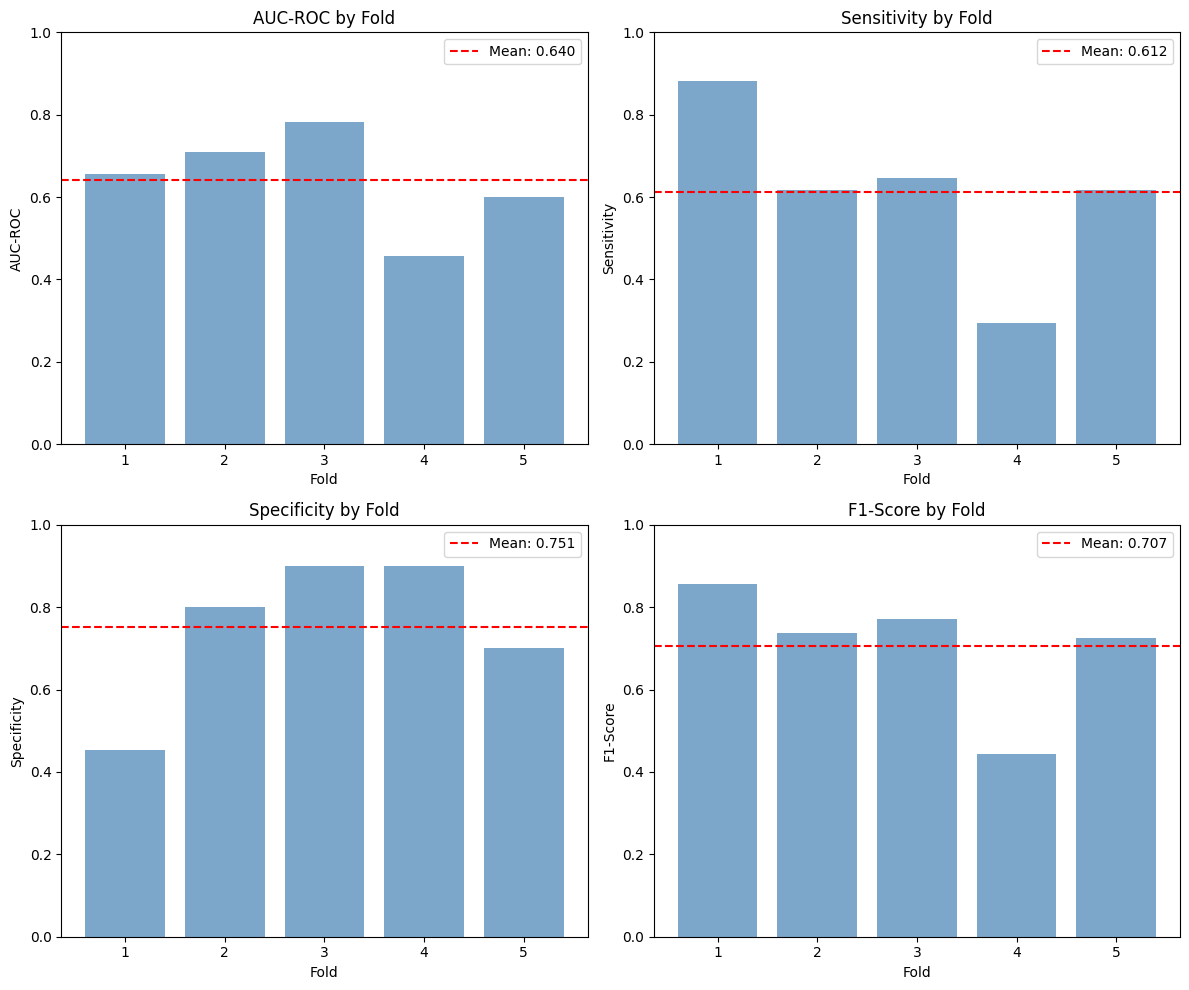

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

metrics = ['val_auc', 'val_sensitivity', 'val_specificity', 'val_f1']
titles = ['AUC-ROC', 'Sensitivity', 'Specificity', 'F1-Score']

for ax, metric, title in zip(axes.flat, metrics, titles):
    values = cv_results[metric]
    ax.bar(range(1, N_FOLDS+1), values, color='steelblue', alpha=0.7)
    ax.axhline(y=np.mean(values), color='red', linestyle='--', label=f'Mean: {np.mean(values):.3f}')
    ax.set_xlabel('Fold')
    ax.set_ylabel(title)
    ax.set_title(f'{title} by Fold')
    ax.set_xticks(range(1, N_FOLDS+1))
    ax.legend()
    ax.set_ylim(0, 1)

plt.tight_layout()
plot_file = os.path.join(GEC_OUTPUT_DIR, 'cv_results.png')
plt.savefig(plot_file, dpi=150, bbox_inches='tight')
print(f'Saved CV plot to {plot_file}')
plt.show()

## Save Best Model and Results

In [32]:
run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
run_name = f"cv_run_{run_timestamp}"
run_artifact_dir = os.path.join(GEC_OUTPUT_DIR, run_name)
os.makedirs(run_artifact_dir, exist_ok=True)

model_filename = f"best_model_fold{best_fold}.pth"
model_file = os.path.join(run_artifact_dir, model_filename)
torch.save(best_model_state, model_file)
print(f"Saved best model to {model_file}")

results_to_save = {
    'run_name': run_name,
    'timestamp': run_timestamp,
    'n_folds': N_FOLDS,
    'cv_results': cv_results,
    'cv_summary': {
        'auc_mean': float(np.mean(cv_results['val_auc'])),
        'auc_std': float(np.std(cv_results['val_auc'])),
        'sensitivity_mean': float(np.mean(cv_results['val_sensitivity'])),
        'specificity_mean': float(np.mean(cv_results['val_specificity'])),
        'f1_mean': float(np.mean(cv_results['val_f1']))
    },
    'best_fold': best_fold,
    'best_threshold': float(best_threshold_overall),
    'config': {
        'in_features': IN_FEATURES,
        'hidden_dim': HIDDEN_DIM,
        'latent_dim': LATENT_DIM,
        'cond_dim': COND_DIM,
        'num_heads': NUM_HEADS,
        'dropout': DROPOUT,
        'classifier_hidden': CLASSIFIER_HIDDEN,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'epochs': EPOCHS,
        'knn_k': KNN_K,
        'file_variant': FILE_VARIANT,
        'freeze_encoder': FREEZE_ENCODER,
        'gaae_checkpoint': GAAE_CHECKPOINT_PATH,
        'dmn_root': DMN_ROOT
    }
}

results_file = os.path.join(run_artifact_dir, "cv_results.json")
cv_results_serializable = {
    k: [float(v) for v in vals] for k, vals in cv_results.items()
}
with open(results_file, 'w') as f:
    json.dump(cv_results_serializable, f, indent=2)
print(f"Saved CV results to {results_file}")
print(f"\nUse this checkpoint directory for testing: {run_artifact_dir}")

Saved best model to /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gec/cv_run_2026-03-23_07-16-21/best_model_fold3.pth
Saved CV results to /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gec/cv_run_2026-03-23_07-16-21/cv_results.json

Use this checkpoint directory for testing: /mnt/e/fyassine/ad-early-detection/MODEL/notebooks/checkpoints_gec/cv_run_2026-03-23_07-16-21
